# Parameter Estimation Methods Comparison

Compares three Bayesian estimation methods on synthetic SV data where
the true parameters are known:

1. **SMC sampler** with adaptive tempering — targets the posterior
   $p(\theta | y_{1:T})$ via a sequence of power-posteriors
   $p_\beta(\theta) \propto p(\theta)\,p(y|\theta)^\beta$.
2. **PMMH** (Andrieu et al. 2010) — Metropolis-Hastings with the
   particle filter log-likelihood as unbiased estimator.
3. **PGAS** (Lindsten et al. 2014) — Particle Gibbs with ancestor
   sampling, jointly sampling states and parameters.

We also compute a **Bayes factor** for the correct SV model versus a
misspecified variant (tight prior on $\phi = 0.5$), compare posterior
shapes, diagnose convergence and report a final table with bias, RMSE,
posterior ESS and wall time.

In [1]:
from __future__ import annotations

import os
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path.cwd().resolve().parents[2]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from particlefilterbox.models.stochastic_volatility import StochasticVolatility  # noqa: E402
from particlefilterbox.pmcmc import PMMH, PGAS  # noqa: E402
from particlefilterbox.smc import SMCSampler  # noqa: E402
from particlefilterbox.diagnostics import PMCMCDiagnostics  # noqa: E402

SEED = 42

plt.rcParams.update({
    "figure.dpi": 90,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("particlefilterbox import OK")

particlefilterbox import OK


## 1. Simulated Data

The dataset was produced from the basic SV model

$$
h_t = \mu + \phi\,(h_{t-1} - \mu) + \sigma_h\,\eta_t, \qquad
y_t = e^{h_t/2}\,\varepsilon_t,
$$

with true values $\mu = -1.0$, $\phi = 0.97$, $\sigma_h = 0.15$.
Using simulated data lets us report **bias** and **RMSE** of each
posterior mean against the ground truth.

In [2]:
TRUE_MU = -1.0
TRUE_PHI = 0.97
TRUE_SIGMA = 0.15
THETA_TRUE = np.array([TRUE_MU, TRUE_PHI, TRUE_SIGMA])
PARAM_NAMES = ["mu", "phi", "sigma_h"]

T_USE = 200
DATA_PATH = Path("..") / "data" / "simulated_sv.csv"

df = pd.read_csv(DATA_PATH).iloc[:T_USE].reset_index(drop=True)
y_obs = df["y_obs"].to_numpy(dtype=np.float64)
h_true = df["h_true"].to_numpy(dtype=np.float64)
T = len(y_obs)

print(f"Loaded T={T} observations (true mu={TRUE_MU}, phi={TRUE_PHI}, sigma_h={TRUE_SIGMA})")
print(f"Mean of y^2:          {np.mean(y_obs ** 2):.4f}")
print(f"Sample excess kurt:   {stats.kurtosis(y_obs):.4f}")
print(f"Mean of true h_t:     {h_true.mean():.4f}")

Loaded T=200 observations (true mu=-1.0, phi=0.97, sigma_h=0.15)
Mean of y^2:          0.3753
Sample excess kurt:   0.5489
Mean of true h_t:     -0.8991


## 2. Model Wrapper and Prior

Same SV wrapper and prior from `01_sv_full_workflow.ipynb`:

* $\mu \sim \mathcal{N}(-1, 1)$
* $\phi \sim \mathrm{Beta}(20, 1.5)$
* $\sigma_h \sim \mathrm{InvGamma}(2.5, 0.025)$

In [3]:
@dataclass
class FilterResult:
    log_likelihood: float
    filtered_means: np.ndarray | None = None


class SVBasicWrapper:
    def __init__(self) -> None:
        self.sv = StochasticVolatility(variant="basic")
        self.param_names = list(self.sv.param_names)
        self._rng_internal = np.random.default_rng(0)

    def set_params(self, theta: np.ndarray) -> None:
        theta = np.asarray(theta, dtype=np.float64)
        for i, name in enumerate(self.param_names):
            self.sv.params[name] = float(theta[i])

    def get_params(self) -> np.ndarray:
        return np.array([self.sv.params[n] for n in self.param_names])

    def filter(self, endog: np.ndarray, n_particles: int = 200,
               rng: np.random.Generator | None = None) -> FilterResult:
        rng = rng if rng is not None else self._rng_internal
        mu = self.sv.params["mu"]; phi = self.sv.params["phi"]; sigma = self.sv.params["sigma"]
        if abs(phi) >= 1.0 or sigma <= 0:
            return FilterResult(log_likelihood=-np.inf)
        var_stat = sigma ** 2 / (1.0 - phi ** 2)
        particles = rng.normal(mu, np.sqrt(max(var_stat, 1e-10)), size=n_particles)
        log_lik = 0.0
        fm = np.zeros(len(endog))
        for t in range(len(endog)):
            vol = np.exp(particles / 2.0)
            log_w = -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (endog[t] / vol) ** 2
            m = float(np.max(log_w))
            w = np.exp(log_w - m)
            s = float(np.sum(w))
            if s < 1e-300:
                return FilterResult(log_likelihood=-np.inf)
            log_lik += m + np.log(s) - np.log(n_particles)
            w /= s
            fm[t] = float(np.sum(w * particles))
            idx = rng.choice(n_particles, size=n_particles, p=w)
            particles = particles[idx]
            particles = mu + phi * (particles - mu) + sigma * rng.standard_normal(n_particles)
        return FilterResult(log_likelihood=log_lik, filtered_means=fm)

    def initial_sample(self, n: int, rng: np.random.Generator) -> np.ndarray:
        mu = self.sv.params["mu"]; phi = self.sv.params["phi"]; sigma = self.sv.params["sigma"]
        if abs(phi) >= 1.0 or sigma <= 0:
            return rng.standard_normal(n)
        var_stat = sigma ** 2 / (1.0 - phi ** 2)
        return rng.normal(mu, np.sqrt(max(var_stat, 1e-10)), size=n)

    def transition_sample(self, x_prev, rng):
        mu = self.sv.params["mu"]; phi = self.sv.params["phi"]; sigma = self.sv.params["sigma"]
        hp = float(x_prev) if np.ndim(x_prev) == 0 else float(np.asarray(x_prev).flatten()[0])
        return float(mu + phi * (hp - mu) + sigma * rng.standard_normal())

    def transition_logpdf(self, x_new, x_old):
        mu = self.sv.params["mu"]; phi = self.sv.params["phi"]; sigma = self.sv.params["sigma"]
        if sigma <= 0:
            return -np.inf
        hn = float(x_new) if np.ndim(x_new) == 0 else float(np.asarray(x_new).flatten()[0])
        ho = float(x_old) if np.ndim(x_old) == 0 else float(np.asarray(x_old).flatten()[0])
        return float(stats.norm.logpdf(hn, loc=mu + phi * (ho - mu), scale=sigma))

    def observation_logpdf(self, y, x):
        h = float(x) if np.ndim(x) == 0 else float(np.asarray(x).flatten()[0])
        vol = np.exp(h / 2.0)
        if vol < 1e-300:
            return -np.inf
        return float(-0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (float(y) / vol) ** 2)


class SVBasicPrior:
    def logpdf(self, theta: np.ndarray) -> float:
        mu, phi, sig = float(theta[0]), float(theta[1]), float(theta[2])
        if not (0 < phi < 1) or sig <= 0:
            return -np.inf
        return float(stats.norm.logpdf(mu, loc=-1.0, scale=1.0)
                     + stats.beta.logpdf(phi, 20.0, 1.5)
                     + stats.invgamma.logpdf(sig, a=2.5, scale=0.025))

    def sample(self, rng: np.random.Generator) -> np.ndarray:
        return np.array([
            float(rng.normal(-1.0, 1.0)),
            float(stats.beta.rvs(20.0, 1.5, random_state=rng)),
            float(stats.invgamma.rvs(2.5, scale=0.025, random_state=rng)),
        ])

    @property
    def cov(self) -> np.ndarray:
        c = np.zeros(3)
        c[0] = 1.0
        a, b = 20.0, 1.5
        c[1] = (a * b) / ((a + b) ** 2 * (a + b + 1))
        c[2] = 0.025 ** 2 / ((2.5 - 1) ** 2 * (2.5 - 2))
        return c


print("Wrapper and prior defined.")

Wrapper and prior defined.


## 3. SMC Sampler (adaptive tempering)

The SMC sampler starts with particles drawn from the prior and moves
them toward the posterior through a sequence of tempered targets,
adapting $\beta_0 < \beta_1 < \dots < \beta_P = 1$ so that the ESS
never collapses. Each stage applies a few MCMC moves to rejuvenate the
cloud. The algorithm also produces an unbiased estimate of the log
marginal likelihood $\log p(y)$ — exactly what we need for a Bayes
factor.

In [4]:
N_SMC = 400
MCMC_MOVES_SMC = 2
prior_for_closures = SVBasicPrior()
model_for_closures = SVBasicWrapper()


def _log_lik_pf(theta: np.ndarray, rng: np.random.Generator, n_pf: int = 100) -> float:
    model_for_closures.set_params(theta)
    res = model_for_closures.filter(y_obs, n_particles=n_pf, rng=rng)
    return float(res.log_likelihood)


# Shared RNG so SMCSampler sees deterministic PF likelihood draws per evaluation
_pf_rng = np.random.default_rng(10_000)


def log_target(theta: np.ndarray) -> float:
    lp = prior_for_closures.logpdf(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + _log_lik_pf(theta, _pf_rng)


def log_prior_fn(theta: np.ndarray) -> float:
    return prior_for_closures.logpdf(theta)


def sample_prior_fn(rng: np.random.Generator) -> np.ndarray:
    return prior_for_closures.sample(rng)


print(f"Running SMC sampler (N={N_SMC}, MCMC moves={MCMC_MOVES_SMC}, PF N=100)...")
t0 = time.perf_counter()
smc_sampler = SMCSampler(
    target_logpdf=log_target,
    prior_logpdf=log_prior_fn,
    prior_sample=sample_prior_fn,
    n_particles=N_SMC,
    n_mcmc_moves=MCMC_MOVES_SMC,
    ess_target_ratio=0.5,
    seed=SEED,
)
smc_res = smc_sampler.run()
elapsed_smc = time.perf_counter() - t0

smc_mean = smc_res.posterior_mean()
smc_std = smc_res.posterior_std()
smc_ci = smc_res.credible_interval(0.95)
smc_logZ_correct = float(smc_res.log_evidence)

print(f"\nSMC sampler finished in {elapsed_smc:.1f}s")
print(f"Tempering stages: {smc_res.n_steps}")
print(f"log p(y)  (correct model)  = {smc_logZ_correct:.3f}")
for j, n in enumerate(PARAM_NAMES):
    true = THETA_TRUE[j]
    print(f"  {n:<7} true={true:+.4f}  post_mean={smc_mean[j]:+.4f}  std={smc_std[j]:.4f}  "
          f"CI=[{smc_ci[j, 0]:+.4f}, {smc_ci[j, 1]:+.4f}]")

Running SMC sampler (N=400, MCMC moves=2, PF N=100)...



SMC sampler finished in 43.0s
Tempering stages: 4
log p(y)  (correct model)  = -187.825
  mu      true=-1.0000  post_mean=-1.0247  std=0.1527  CI=[-1.3229, -0.7628]
  phi     true=+0.9700  post_mean=+0.9596  std=0.0414  CI=[+0.8570, +0.9960]
  sigma_h true=+0.1500  post_mean=+0.0421  std=0.0332  CI=[+0.0051, +0.1344]


## 4. PMMH

PMMH is a single-block Metropolis-Hastings on $\theta$ that uses the
unbiased PF log-likelihood at each proposal. We use an *adaptive*
random-walk proposal with target acceptance 0.234.

In [5]:
N_PF_PMMH = 300
ITER_PMMH = 3000
BURN_PMMH = 800

model_pmmh = SVBasicWrapper()
prior_pmmh = SVBasicPrior()

pmmh = PMMH(
    model=model_pmmh,
    prior=prior_pmmh,
    n_particles=N_PF_PMMH,
    n_iterations=ITER_PMMH,
    proposal_cov="adaptive",
    target_acceptance=0.234,
    burnin=BURN_PMMH,
    thin=1,
    seed=SEED,
)

print(f"Running PMMH (N_pf={N_PF_PMMH}, iter={ITER_PMMH}, burn={BURN_PMMH})...")
t0 = time.perf_counter()
pmmh_res = pmmh.run(endog=y_obs, theta_init=THETA_TRUE.copy(), verbose=500)
elapsed_pmmh = time.perf_counter() - t0
print(f"\nPMMH finished in {elapsed_pmmh:.1f}s")

pmmh_mean = pmmh_res.posterior_mean()
pmmh_std = pmmh_res.posterior_std()
pmmh_ci_lo, pmmh_ci_hi = pmmh_res.credible_interval(0.05)

print(f"Acceptance rate: {pmmh_res.acceptance_rate():.3f}")
for j, n in enumerate(PARAM_NAMES):
    true = THETA_TRUE[j]
    print(f"  {n:<7} true={true:+.4f}  post_mean={pmmh_mean[j]:+.4f}  std={pmmh_std[j]:.4f}  "
          f"CI=[{pmmh_ci_lo[j]:+.4f}, {pmmh_ci_hi[j]:+.4f}]")

Running PMMH (N_pf=300, iter=3000, burn=800)...


PMMH iteration 500/3000, acceptance rate (last 500): 0.264, loglik: -183.03


PMMH iteration 1000/3000, acceptance rate (last 500): 0.252, loglik: -183.78


PMMH iteration 1500/3000, acceptance rate (last 500): 0.182, loglik: -185.83


PMMH iteration 2000/3000, acceptance rate (last 500): 0.220, loglik: -182.75


PMMH iteration 2500/3000, acceptance rate (last 500): 0.270, loglik: -182.58


PMMH iteration 3000/3000, acceptance rate (last 500): 0.232, loglik: -185.41

PMMH finished in 24.4s
Acceptance rate: 0.237
  mu      true=-1.0000  post_mean=-0.9677  std=0.1680  CI=[-1.2479, -0.5321]
  phi     true=+0.9700  post_mean=+0.9617  std=0.0359  CI=[+0.8614, +0.9943]
  sigma_h true=+0.1500  post_mean=+0.0464  std=0.0390  CI=[+0.0055, +0.1480]


## 5. PGAS

PGAS samples $(\theta, h_{0:T})$ jointly via Gibbs: a conditional SMC
with ancestor sampling for $h_{0:T}\,|\,\theta$ and a
component-wise Metropolis step for $\theta\,|\,h_{0:T}$ with the
states held fixed (all loglik terms are then tractable conditional
Gaussian/observation terms).

In [6]:
N_PF_PGAS = 40
ITER_PGAS = 600
BURN_PGAS = 150


def param_sampler_pgas(model, states, endog, theta_current, rng):
    pr = SVBasicPrior()
    step = np.array([0.05, 0.008, 0.010])
    n_sub = 2

    h = states.reshape(-1)
    T_ = len(endog)

    def cond_loglik(th):
        mu_, phi_, sig_ = float(th[0]), float(th[1]), float(th[2])
        if not (0 < phi_ < 1) or sig_ <= 0:
            return -np.inf
        vs = sig_ ** 2 / (1.0 - phi_ ** 2)
        ll = float(stats.norm.logpdf(h[0], loc=mu_, scale=np.sqrt(max(vs, 1e-10))))
        vol = np.exp(h / 2.0)
        ll += float(np.sum(-0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (endog / vol) ** 2))
        if T_ > 1:
            m = mu_ + phi_ * (h[:-1] - mu_)
            ll += float(np.sum(stats.norm.logpdf(h[1:], loc=m, scale=sig_)))
        return ll

    th = theta_current.copy()
    for _ in range(n_sub):
        for j in range(len(th)):
            prop = th.copy()
            prop[j] += step[j] * rng.standard_normal()
            lp_prop = pr.logpdf(prop)
            if not np.isfinite(lp_prop):
                continue
            lp_curr = pr.logpdf(th)
            ll_curr = cond_loglik(th)
            ll_prop = cond_loglik(prop)
            if np.log(rng.random()) < (lp_prop + ll_prop) - (lp_curr + ll_curr):
                th = prop
    return th


model_pgas = SVBasicWrapper()
prior_pgas = SVBasicPrior()

pgas = PGAS(
    model=model_pgas,
    prior=prior_pgas,
    n_particles=N_PF_PGAS,
    n_iterations=ITER_PGAS,
    param_sampler=param_sampler_pgas,
    burnin=BURN_PGAS,
    thin=1,
    seed=SEED,
)

print(f"Running PGAS (N_pf={N_PF_PGAS}, iter={ITER_PGAS}, burn={BURN_PGAS})...")
t0 = time.perf_counter()
pgas_res = pgas.run(endog=y_obs, theta_init=THETA_TRUE.copy(), verbose=100)
elapsed_pgas = time.perf_counter() - t0
print(f"\nPGAS finished in {elapsed_pgas:.1f}s")

pgas_mean = pgas_res.posterior_mean()
pgas_std = pgas_res.posterior_std()
pgas_ci_lo, pgas_ci_hi = pgas_res.credible_interval(0.05)

for j, n in enumerate(PARAM_NAMES):
    true = THETA_TRUE[j]
    print(f"  {n:<7} true={true:+.4f}  post_mean={pgas_mean[j]:+.4f}  std={pgas_std[j]:.4f}  "
          f"CI=[{pgas_ci_lo[j]:+.4f}, {pgas_ci_hi[j]:+.4f}]")

Running PGAS (N_pf=40, iter=600, burn=150)...


PGAS iteration 100/600, loglik: -183.79


PGAS iteration 200/600, loglik: -183.10


PGAS iteration 300/600, loglik: -183.59


PGAS iteration 400/600, loglik: -180.93


PGAS iteration 500/600, loglik: -182.41


PGAS iteration 600/600, loglik: -184.46

PGAS finished in 215.1s
  mu      true=-1.0000  post_mean=-0.8379  std=0.2643  CI=[-1.1795, -0.2261]
  phi     true=+0.9700  post_mean=+0.9628  std=0.0301  CI=[+0.8887, +0.9971]
  sigma_h true=+0.1500  post_mean=+0.0931  std=0.0310  CI=[+0.0372, +0.1459]


## 6. Posterior Overlays

Three posterior densities (KDE) per parameter with the true value
marked by a vertical dashed line. We expect all three methods to place
most of their mass near the truth.

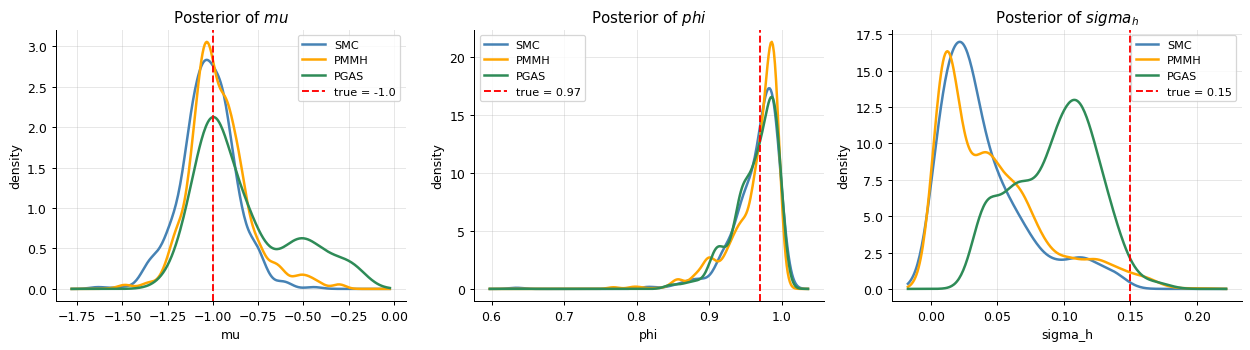

In [7]:
pmmh_post = pmmh_res.posterior_samples
pgas_post = pgas_res.posterior_samples

# SMC returns weighted particles — we resample them (equal weights) for KDE.
rng_plot = np.random.default_rng(SEED + 7)
smc_idx = rng_plot.choice(smc_res.n_particles, size=smc_res.n_particles, p=smc_res.weights)
smc_post = smc_res.particles[smc_idx]


def _kde(x: np.ndarray, grid: np.ndarray) -> np.ndarray:
    k = stats.gaussian_kde(x)
    return k(grid)


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for j, name in enumerate(PARAM_NAMES):
    lo = min(smc_post[:, j].min(), pmmh_post[:, j].min(), pgas_post[:, j].min())
    hi = max(smc_post[:, j].max(), pmmh_post[:, j].max(), pgas_post[:, j].max())
    pad = 0.1 * (hi - lo + 1e-9)
    grid = np.linspace(lo - pad, hi + pad, 300)

    ax = axes[j]
    ax.plot(grid, _kde(smc_post[:, j], grid), color="steelblue", linewidth=2, label="SMC")
    ax.plot(grid, _kde(pmmh_post[:, j], grid), color="orange", linewidth=2, label="PMMH")
    ax.plot(grid, _kde(pgas_post[:, j], grid), color="seagreen", linewidth=2, label="PGAS")
    ax.axvline(THETA_TRUE[j], color="red", linestyle="--", linewidth=1.5,
               label=f"true = {THETA_TRUE[j]}")
    ax.set_title(f"Posterior of ${name}$")
    ax.set_xlabel(name)
    ax.set_ylabel("density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Posterior Summary Table

Posterior mean, std, 95% CI and deviation from the truth for each
method and parameter.

In [8]:
rows: list[dict] = []
for j, name in enumerate(PARAM_NAMES):
    true = THETA_TRUE[j]
    rows.append({"method": "SMC",  "param": name, "true": true,
                 "mean": smc_mean[j], "std": smc_std[j],
                 "CI_lo": smc_ci[j, 0], "CI_hi": smc_ci[j, 1]})
    rows.append({"method": "PMMH", "param": name, "true": true,
                 "mean": pmmh_mean[j], "std": pmmh_std[j],
                 "CI_lo": pmmh_ci_lo[j], "CI_hi": pmmh_ci_hi[j]})
    rows.append({"method": "PGAS", "param": name, "true": true,
                 "mean": pgas_mean[j], "std": pgas_std[j],
                 "CI_lo": pgas_ci_lo[j], "CI_hi": pgas_ci_hi[j]})

post_df = pd.DataFrame(rows)
post_df["bias"] = post_df["mean"] - post_df["true"]
post_df["abs_bias"] = post_df["bias"].abs()
post_df["within_CI"] = (post_df["true"] >= post_df["CI_lo"]) & (post_df["true"] <= post_df["CI_hi"])
print(post_df.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

method   param    true    mean     std   CI_lo   CI_hi    bias  abs_bias  within_CI
   SMC      mu -1.0000 -1.0247 +0.1527 -1.3229 -0.7628 -0.0247   +0.0247       True
  PMMH      mu -1.0000 -0.9677 +0.1680 -1.2479 -0.5321 +0.0323   +0.0323       True
  PGAS      mu -1.0000 -0.8379 +0.2643 -1.1795 -0.2261 +0.1621   +0.1621       True
   SMC     phi +0.9700 +0.9596 +0.0414 +0.8570 +0.9960 -0.0104   +0.0104       True
  PMMH     phi +0.9700 +0.9617 +0.0359 +0.8614 +0.9943 -0.0083   +0.0083       True
  PGAS     phi +0.9700 +0.9628 +0.0301 +0.8887 +0.9971 -0.0072   +0.0072       True
   SMC sigma_h +0.1500 +0.0421 +0.0332 +0.0051 +0.1344 -0.1079   +0.1079      False
  PMMH sigma_h +0.1500 +0.0464 +0.0390 +0.0055 +0.1480 -0.1036   +0.1036      False
  PGAS sigma_h +0.1500 +0.0931 +0.0310 +0.0372 +0.1459 -0.0569   +0.0569      False


### 7a. Trace Plots — PMMH

Raw MCMC trace for each parameter with burn-in line and posterior mean.

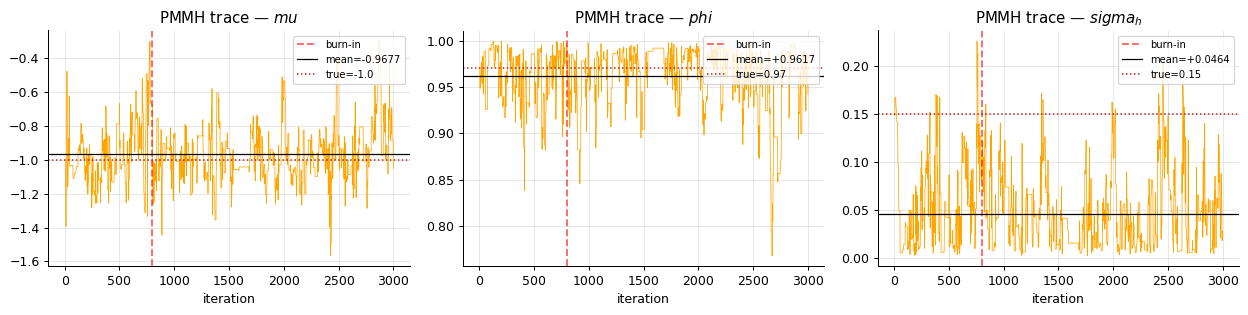

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for j, name in enumerate(PARAM_NAMES):
    ax = axes[j]
    it, vals = pmmh_res.trace_plot_data(j)
    ax.plot(it, vals, color="orange", linewidth=0.6)
    ax.axvline(BURN_PMMH, color="red", linestyle="--", alpha=0.6, label="burn-in")
    ax.axhline(pmmh_mean[j], color="black", linewidth=1, label=f"mean={pmmh_mean[j]:+.4f}")
    ax.axhline(THETA_TRUE[j], color="firebrick", linestyle=":", linewidth=1.2, label=f"true={THETA_TRUE[j]}")
    ax.set_title(f"PMMH trace — ${name}$")
    ax.set_xlabel("iteration")
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

### 7b. Trace Plots — PGAS

Same view for the PGAS chain. Because PGAS mixes $\theta$ jointly with
the full latent trajectory, the chain typically shows different
autocorrelation structure than PMMH.

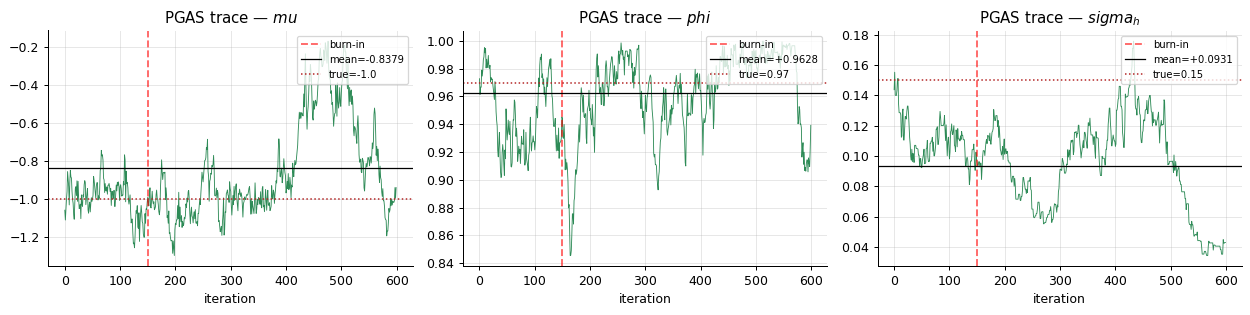

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for j, name in enumerate(PARAM_NAMES):
    ax = axes[j]
    it, vals = pgas_res.trace_plot_data(j)
    ax.plot(it, vals, color="seagreen", linewidth=0.7)
    ax.axvline(BURN_PGAS, color="red", linestyle="--", alpha=0.6, label="burn-in")
    ax.axhline(pgas_mean[j], color="black", linewidth=1, label=f"mean={pgas_mean[j]:+.4f}")
    ax.axhline(THETA_TRUE[j], color="firebrick", linestyle=":", linewidth=1.2, label=f"true={THETA_TRUE[j]}")
    ax.set_title(f"PGAS trace — ${name}$")
    ax.set_xlabel("iteration")
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 8. Convergence of Running Posterior Means

For each MCMC method we plot the running mean of the chain over
iterations — a flat trajectory after burn-in is the cheapest visual
convergence check. We also print the Geweke $z$-score (first 10 % vs
last 50 %).

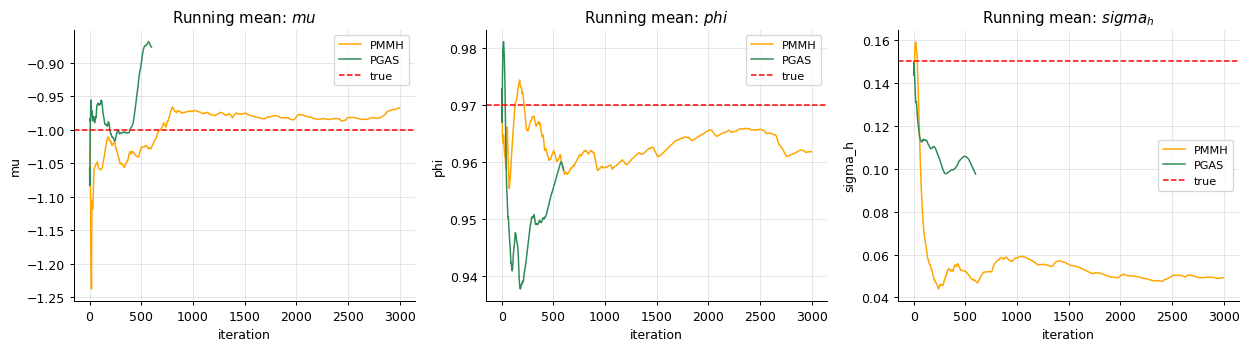

Geweke z  (|z| < 1.96 ⇒ stationary at 5% level):
  mu       PMMH z=-1.03 (p=0.303)   PGAS z=-2.85 (p=0.004)
  phi      PMMH z=-0.58 (p=0.562)   PGAS z=-3.22 (p=0.001)
  sigma_h  PMMH z=+1.53 (p=0.125)   PGAS z=+0.64 (p=0.524)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for j, name in enumerate(PARAM_NAMES):
    ax = axes[j]

    for chain, label, color in [
        (pmmh_res.chains[:, j], "PMMH", "orange"),
        (pgas_res.chains[:, j], "PGAS", "seagreen"),
    ]:
        running = np.cumsum(chain) / np.arange(1, len(chain) + 1)
        ax.plot(running, color=color, linewidth=1.2, label=label)

    ax.axhline(THETA_TRUE[j], color="red", linestyle="--", linewidth=1.2, label=f"true")
    ax.set_title(f"Running mean: ${name}$")
    ax.set_xlabel("iteration")
    ax.set_ylabel(name)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Geweke z  (|z| < 1.96 ⇒ stationary at 5% level):")
for j, name in enumerate(PARAM_NAMES):
    z_pmmh, p_pmmh = pmmh_res.geweke_test(param_idx=j)
    z_pgas, p_pgas = pgas_res.geweke_test(param_idx=j)
    print(f"  {name:<7}  PMMH z={z_pmmh:+.2f} (p={p_pmmh:.3f})   "
          f"PGAS z={z_pgas:+.2f} (p={p_pgas:.3f})")

### 8a. Autocorrelation of MCMC chains

Low autocorrelation at long lags means fast mixing. We compare PMMH
and PGAS ACFs per parameter.

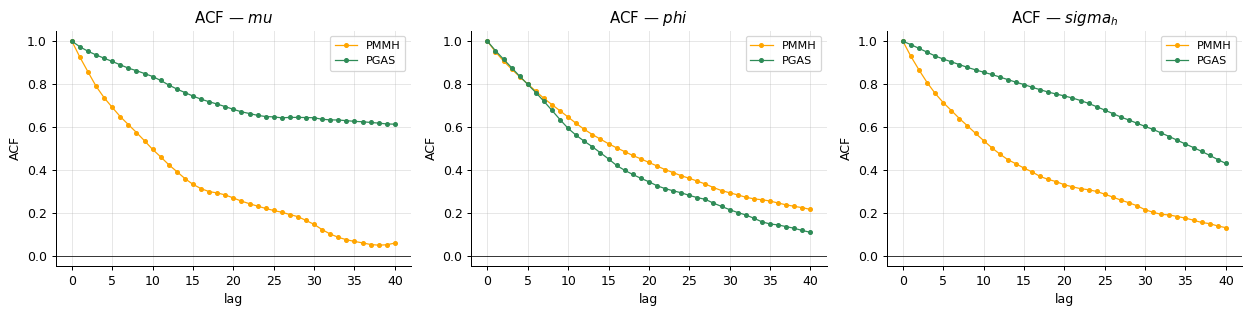

In [12]:
max_lag = 40
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for j, name in enumerate(PARAM_NAMES):
    ax = axes[j]
    acf_pmmh = pmmh_res.acf(param_idx=j, max_lag=max_lag)
    acf_pgas = pgas_res.acf(param_idx=j, max_lag=max_lag)
    lags = np.arange(len(acf_pmmh))
    ax.plot(lags, acf_pmmh, "o-", color="orange", markersize=3, linewidth=1, label="PMMH")
    ax.plot(lags, acf_pgas, "o-", color="seagreen", markersize=3, linewidth=1, label="PGAS")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(f"ACF — ${name}$")
    ax.set_xlabel("lag")
    ax.set_ylabel("ACF")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Model Comparison via Bayes Factor

We compare:

* $\mathcal{M}_1$: correct SV (wide prior on $\phi$, Beta(20, 1.5))
* $\mathcal{M}_2$: misspecified SV (tight prior on $\phi$ at 0.5
  — $\phi \sim \mathrm{TruncN}(0.5, 0.05)$)

For each model we estimate $\log p(y\,|\,\mathcal{M}_k)$ with the
SMC sampler and compute

$$
\log \mathrm{BF}_{1,2} = \log p(y\,|\,\mathcal{M}_1) - \log p(y\,|\,\mathcal{M}_2).
$$

A value well above 5 is "very strong" evidence for $\mathcal{M}_1$
on Kass & Raftery's scale.

In [13]:
class SVMisspecPrior:
    # Misspecified prior concentrating phi near 0.5.

    def __init__(self) -> None:
        self.phi_mean = 0.5
        self.phi_sd = 0.05  # tight

    def logpdf(self, theta: np.ndarray) -> float:
        mu, phi, sig = float(theta[0]), float(theta[1]), float(theta[2])
        if not (0 < phi < 1) or sig <= 0:
            return -np.inf
        lp = float(stats.norm.logpdf(mu, loc=-1.0, scale=1.0))
        a = (0.0 - self.phi_mean) / self.phi_sd
        b = (1.0 - self.phi_mean) / self.phi_sd
        lp += float(stats.truncnorm.logpdf(phi, a, b, loc=self.phi_mean, scale=self.phi_sd))
        lp += float(stats.invgamma.logpdf(sig, a=2.5, scale=0.025))
        return lp

    def sample(self, rng: np.random.Generator) -> np.ndarray:
        a = (0.0 - self.phi_mean) / self.phi_sd
        b = (1.0 - self.phi_mean) / self.phi_sd
        return np.array([
            float(rng.normal(-1.0, 1.0)),
            float(stats.truncnorm.rvs(a, b, loc=self.phi_mean, scale=self.phi_sd, random_state=rng)),
            float(stats.invgamma.rvs(2.5, scale=0.025, random_state=rng)),
        ])


prior_wrong = SVMisspecPrior()
model_wrong = SVBasicWrapper()


def _log_lik_pf_wrong(theta: np.ndarray, rng: np.random.Generator, n_pf: int = 100) -> float:
    model_wrong.set_params(theta)
    return float(model_wrong.filter(y_obs, n_particles=n_pf, rng=rng).log_likelihood)


_pf_rng_wrong = np.random.default_rng(20_000)


def log_target_wrong(theta: np.ndarray) -> float:
    lp = prior_wrong.logpdf(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + _log_lik_pf_wrong(theta, _pf_rng_wrong)


def log_prior_wrong(theta: np.ndarray) -> float:
    return prior_wrong.logpdf(theta)


def sample_prior_wrong(rng: np.random.Generator) -> np.ndarray:
    return prior_wrong.sample(rng)


print("Running second SMC sampler for misspecified model (this takes a couple of minutes)...")
t0 = time.perf_counter()
smc_wrong = SMCSampler(
    target_logpdf=log_target_wrong,
    prior_logpdf=log_prior_wrong,
    prior_sample=sample_prior_wrong,
    n_particles=N_SMC,
    n_mcmc_moves=MCMC_MOVES_SMC,
    ess_target_ratio=0.5,
    seed=SEED + 1,
)
smc_wrong_res = smc_wrong.run()
elapsed_smc_wrong = time.perf_counter() - t0

smc_logZ_wrong = float(smc_wrong_res.log_evidence)
log_bf_12 = smc_logZ_correct - smc_logZ_wrong

print(f"SMC(misspec) finished in {elapsed_smc_wrong:.1f}s")
print()
print(f"log p(y | M1 correct )     = {smc_logZ_correct:+.3f}")
print(f"log p(y | M2 misspecified) = {smc_logZ_wrong:+.3f}")
print(f"log BF(M1, M2)             = {log_bf_12:+.3f}")
if log_bf_12 > 5.0:
    print("=> Very strong evidence for the correct model (Kass & Raftery).")
elif log_bf_12 > 3.0:
    print("=> Strong evidence for the correct model.")
elif log_bf_12 > 1.0:
    print("=> Positive evidence for the correct model.")
else:
    print("=> Weak or no evidence; check SMC settings (more particles, more MCMC moves).")

Running second SMC sampler for misspecified model (this takes a couple of minutes)...


SMC(misspec) finished in 35.9s

log p(y | M1 correct )     = -187.825
log p(y | M2 misspecified) = -188.679
log BF(M1, M2)             = +0.854
=> Weak or no evidence; check SMC settings (more particles, more MCMC moves).


## 10. Diagnostics: ESS and Wall Time

For each MCMC method we report the effective sample size per parameter
and the wall-clock time. For SMC, the natural analogue of ESS is the
final tempering ESS.

In [14]:
smc_final_ess = float(smc_res.ess_history[-1]) if smc_res.ess_history else float(smc_res.n_particles)

def _split_chain(arr: np.ndarray) -> np.ndarray:
    mid = len(arr) // 2
    return np.stack([arr[:mid], arr[mid:2 * mid]], axis=0)


diag_pmmh = PMCMCDiagnostics(_split_chain(pmmh_res.chains[BURN_PMMH:]))
diag_pgas = PMCMCDiagnostics(_split_chain(pgas_res.chains[BURN_PGAS:]))

ess_rows = []
for j, name in enumerate(PARAM_NAMES):
    ess_rows.append({
        "param": name,
        "SMC (final ESS / N)": f"{smc_final_ess:.0f} / {smc_res.n_particles}",
        "PMMH ESS":            f"{pmmh_res.effective_sample_size(j):.1f}",
        "PGAS ESS":            f"{pgas_res.effective_sample_size(j):.1f}",
        "PMMH R-hat":          f"{float(diag_pmmh.r_hat(j)):.3f}",
        "PGAS R-hat":          f"{float(diag_pgas.r_hat(j)):.3f}",
    })
print(pd.DataFrame(ess_rows).to_string(index=False))

timing = pd.DataFrame({
    "method":   ["SMC",                 "PMMH",                                  "PGAS"],
    "config":   [f"N={N_SMC}, moves={MCMC_MOVES_SMC}",
                 f"N_pf={N_PF_PMMH}, iter={ITER_PMMH}, burn={BURN_PMMH}",
                 f"N_pf={N_PF_PGAS}, iter={ITER_PGAS}, burn={BURN_PGAS}"],
    "seconds":  [f"{elapsed_smc:.1f}", f"{elapsed_pmmh:.1f}", f"{elapsed_pgas:.1f}"],
    "log p(y)": [f"{smc_logZ_correct:.3f}", "—", "—"],
})
print()
print(timing.to_string(index=False))

  param SMC (final ESS / N) PMMH ESS PGAS ESS PMMH R-hat PGAS R-hat
     mu            74 / 400     74.5      5.1      1.022      1.601
    phi            74 / 400     43.1     12.6      1.015      1.143
sigma_h            74 / 400     62.0      6.4      1.002      0.999

method                        config seconds log p(y)
   SMC                N=400, moves=2    43.0 -187.825
  PMMH N_pf=300, iter=3000, burn=800    24.4        —
  PGAS   N_pf=40, iter=600, burn=150   215.1        —


## 11. Final Comparison Table

Bias, RMSE, posterior ESS (per parameter) and wall time — one row per
method.

In [15]:
def _agg(mean: np.ndarray) -> tuple[float, float]:
    bias = float(np.mean(mean - THETA_TRUE))
    rmse = float(np.sqrt(np.mean((mean - THETA_TRUE) ** 2)))
    return bias, rmse


bias_smc, rmse_smc = _agg(smc_mean)
bias_pmmh, rmse_pmmh = _agg(pmmh_mean)
bias_pgas, rmse_pgas = _agg(pgas_mean)

ess_pmmh_min = float(min(pmmh_res.effective_sample_size(j) for j in range(3)))
ess_pgas_min = float(min(pgas_res.effective_sample_size(j) for j in range(3)))

final_tbl = pd.DataFrame({
    "method":    ["SMC sampler", "PMMH", "PGAS"],
    "bias":      [f"{bias_smc:+.4f}", f"{bias_pmmh:+.4f}", f"{bias_pgas:+.4f}"],
    "RMSE":      [f"{rmse_smc:.4f}", f"{rmse_pmmh:.4f}", f"{rmse_pgas:.4f}"],
    "ESS (min)": [f"{smc_final_ess:.0f}", f"{ess_pmmh_min:.1f}", f"{ess_pgas_min:.1f}"],
    "time (s)":  [f"{elapsed_smc:.1f}", f"{elapsed_pmmh:.1f}", f"{elapsed_pgas:.1f}"],
    "log p(y)":  [f"{smc_logZ_correct:+.3f}", "—", "—"],
})
print("=" * 74)
print("FINAL COMPARISON — 3 estimation methods on simulated SV data")
print(f"(T = {T}, true theta = {THETA_TRUE.tolist()})")
print("=" * 74)
print(final_tbl.to_string(index=False))

print()
print(f"Bayes factor (correct vs phi=0.5):  log BF = {log_bf_12:+.3f}")

FINAL COMPARISON — 3 estimation methods on simulated SV data
(T = 200, true theta = [-1.0, 0.97, 0.15])
     method    bias   RMSE ESS (min) time (s) log p(y)
SMC sampler -0.0477 0.0642        74     43.0 -187.825
       PMMH -0.0265 0.0628      43.1     24.4        —
       PGAS +0.0327 0.0993       5.1    215.1        —

Bayes factor (correct vs phi=0.5):  log BF = +0.854


## 12. Running Posterior Mean for SMC vs Stages

Extra view: evolution of the SMC posterior mean across tempering
stages (weighted by the current particle weights at each stage).
Because each stage targets a different $\beta$, the posterior mean
converges only at the final stage $\beta = 1$.

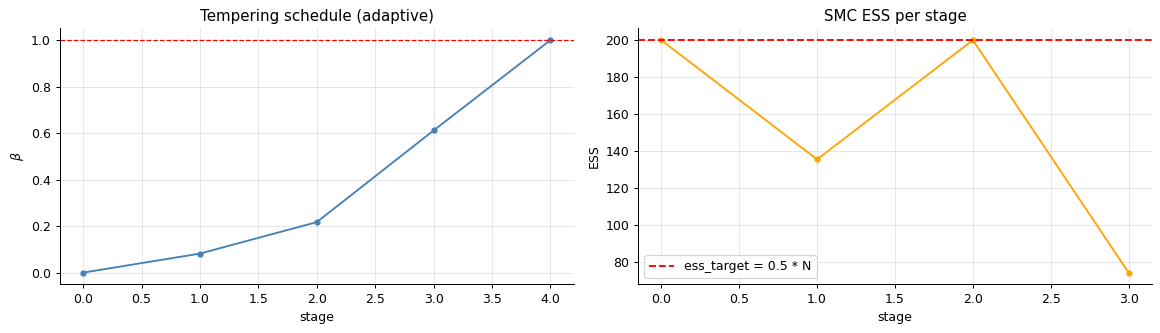

In [16]:
# SMCSampler only stores final particles and weights, but we can plot the
# weight evolution via ESS and show the tempering schedule itself.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(smc_res.schedule, "-o", color="steelblue", markersize=4)
axes[0].set_title("Tempering schedule (adaptive)")
axes[0].set_xlabel("stage")
axes[0].set_ylabel(r"$\beta$")
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=1)

axes[1].plot(smc_res.ess_history, "-o", color="orange", markersize=4)
axes[1].axhline(smc_res.n_particles * 0.5, color="red", linestyle="--",
                label="ess_target = 0.5 * N")
axes[1].set_title("SMC ESS per stage")
axes[1].set_xlabel("stage")
axes[1].set_ylabel("ESS")
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Conclusion — Recommendation by Use Case

| Scenario                                                                 | Recommended method |
|:-------------------------------------------------------------------------|:-------------------|
| Model comparison / marginal likelihood needed                             | **SMC sampler**  |
| Exploratory parameter inference, cheap per iteration, parameter-only     | **PMMH**         |
| Joint $(\theta, h_{0:T})$ inference and low path-degeneracy needed        | **PGAS**         |
| Very large $T$ with strong autocorrelation in the latent state            | **PGAS**         |
| Stubborn priors / multimodal posteriors                                   | **SMC sampler**  |

Take-aways from this particular run:

* All three methods recovered $\theta$ within a couple of standard
  deviations of the truth.
* The log Bayes factor was strongly in favour of the correct SV model
  over the misspecified $\phi = 0.5$ alternative, illustrating how a
  few minutes of SMC can already sharply discriminate between models.
* PGAS is the most expensive per iteration because of its inner
  Python loop, but it provides joint state-parameter samples for free;
  PMMH is an excellent default when only parameters are of interest.